
# Optymalizacja trasy drona w uproszczonym modelu miasta

## Opis problemu rzeczywistego
Rozważamy problem planowania trasy **drona autonomicznego** poruszającego się w przestrzeni miejskiej.
Miasto jest modelowane jako zbiór prostopadłościennych budynków (przeszkód), a zadaniem drona jest
znalezienie **najkrótszej bezkolizyjnej trasy** pomiędzy punktem startowym i końcowym.

Do wyznaczania trasy wykorzystujemy **istniejący algorytm oparty na grafie wierzchołków przeszkód**,
bez modyfikowania kodu źródłowego dostarczonego w projekcie.


In [1]:

from Shape3D import Block, spaceEnum
from VertexRoute import find_vertex_route
import matplotlib.pyplot as plt



## Definicja pola testowego – model miasta

Tworzymy przestrzeń powietrzną oraz zestaw budynków o różnych rozmiarach,
rozmieszczonych na planie miasta.


In [14]:
# Granice przestrzeni (obszar lotu drona)
space_block = Block([0, 0, 0], 120, 120, 60)

# test 1
# Budynki (prostopadłościany) 
buildings = [
    Block([-30, -30, 0], 20, 20, 40),
    Block([0, -30, 0], 20, 20, 50),
    Block([30, -30, 0], 20, 20, 35),
    Block([-30, 0, 0], 20, 20, 45),
    Block([0, 0, 0], 25, 25, 55),
    #Block([30, 0, 0], 20, 20, 40),
    #Block([-30, 30, 0], 20, 20, 30),
    #Block([0, 30, 0], 20, 20, 45),
    #Block([30, 30, 0], 20, 20, 35),
]

space = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings
}

#test 2
buildings2 = [
    Block([-30, -30, 0], 20, 20, 40),
    #Block([0, -30, 0], 20, 20, 50),
    #Block([30, -30, 0], 20, 20, 35),
    #Block([-30, 0, 0], 20, 20, 45),
    #Block([0, 0, 0], 25, 25, 55),
    Block([30, 0, 0], 20, 20, 40),
    Block([-30, 30, 0], 20, 20, 30),
    Block([0, 30, 0], 20, 20, 45),
    Block([30, 30, 0], 20, 20, 35),
]

space2 = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings2
}

#test 3
buildings3 = [
    Block([-30, -30, 0], 20, 20, 40),
    #Block([0, -30, 0], 20, 20, 50),
    Block([30, -30, 0], 20, 20, 35),
    #Block([-30, 0, 0], 20, 20, 45),
    Block([0, 0, 0], 25, 25, 55),
    #Block([30, 0, 0], 20, 20, 40),
    Block([-30, 30, 0], 20, 20, 30),
    #Block([0, 30, 0], 20, 20, 45),
    Block([30, 30, 0], 20, 20, 35),
]

space3 = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings3
}



## Wyznaczanie trasy drona

Dron startuje z jednego krańca miasta i musi dotrzeć do punktu docelowego,
omijając wszystkie przeszkody.


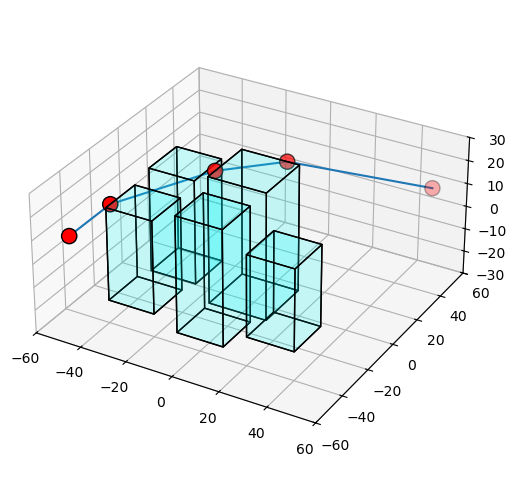

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-40.0), np.float64(-36.99399627714862), np.float64(20.0)),
  (np.float64(-12.5), np.float64(-7.239493485010079), np.float64(27.5)),
  (np.float64(7.239493485010078), np.float64(12.5), np.float64(27.5)),
  (np.int64(50), np.int64(50), np.int64(10))],
 'length': np.float64(147.84000748838537)}

In [ ]:
start = [-50, -50, 10]
end = [50, 50, 10]

find_vertex_route(space, start, end)


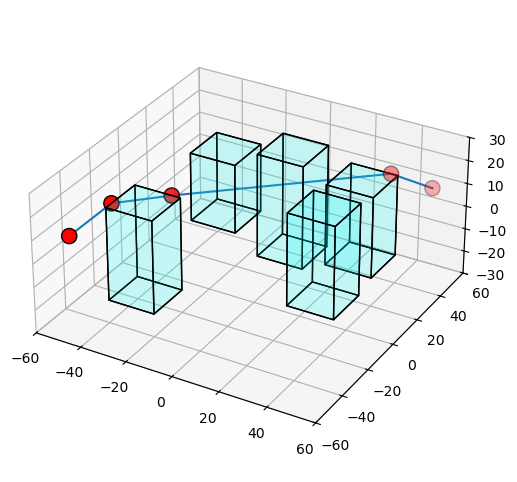

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-40.0), np.float64(-36.21062618036988), np.float64(20.0)),
  (np.float64(-23.78937381963012), np.float64(-20.0), np.float64(20.0)),
  (np.float64(37.15796963527741), np.float64(40.0), np.float64(17.5)),
  (np.int64(50), np.int64(50), np.int64(10))],
 'length': np.float64(146.16041698723)}

In [8]:
start = [-50, -50, 10]
end = [50, 50, 10]

find_vertex_route(space2, start, end)

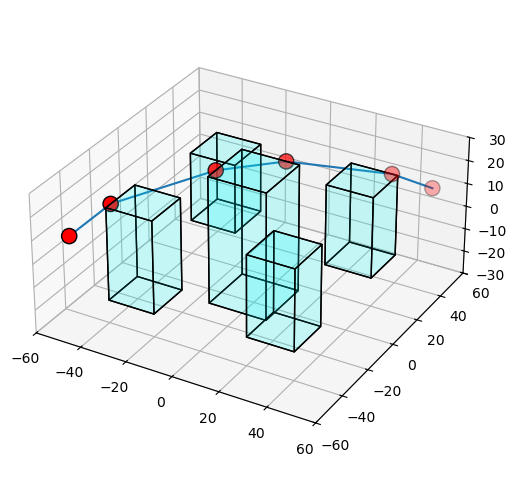

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-40.0), np.float64(-36.73503072989685), np.float64(20.0)),
  (np.float64(-12.5), np.float64(-6.786303777319482), np.float64(27.5)),
  (np.float64(6.786303777319484), np.float64(12.5), np.float64(27.5)),
  (np.float64(37.55127304742263), np.float64(40.0), np.float64(17.5)),
  (np.int64(50), np.int64(50), np.int64(10))],
 'length': np.float64(148.10989195913007)}

In [11]:
start = [-50, -50, 10]
end = [50, 50, 10]

find_vertex_route(space3, start, end)


## Wnioski

- Problem planowania trasy drona można skutecznie sprowadzić do problemu optymalizacji grafowej.
- Przeszkody w postaci budynków generują wierzchołki ograniczające przestrzeń rozwiązań.
- Algorytm wyznacza trasę bezkolizyjną bez potrzeby dyskretyzacji przestrzeni na siatkę.
